# 静态场景 - 比例扫描实验
固定总密度，扫描不同业务比例下的性能表现

## 初始化环境

In [1]:
import sys
sys.path.insert(0, '.')

from algo.logger import reset_logger
reset_logger()

In [2]:
from dataclasses import replace
from pathlib import Path
from typing import Dict
from copy import deepcopy
import math
import torch
import yaml
import os
import numpy as np
from collections import OrderedDict
import importlib
from matplotlib import pyplot as plt

from algo import HPPOConfig, build_hppo_modules, train_hppo
from algo.logger import get_logger, setup_logger
from env import (
    MACSimulatorConfig,
    SatelliteMACEnv,
    SatelliteMACEnvConfig,
    default_simulator_config,
    build_gym_env,
)
import matplotlib.font_manager as font_manager
import scienceplots
plt.style.use(['science', 'no-latex'])
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Noto Sans SC',]

# 导入评估工具（包括static_sensitivity_config和load_yaml_config）
from utils.evaluate import (
    static_sensitivity_config,
    train_and_evaluate_scenario,
    print_results_summary,
    load_yaml_config
)
import baseline
importlib.reload(baseline)
from baseline import run_episode


## 比例扫描配置生成

In [3]:
def run_ratio_sweep_experiment():
    """
    比例扫描实验：固定总密度，扫描业务比例
    用于绘制：Performance vs. CBRA_Ratio 曲线
    """
    # 1. 固定总密度
    fixed_density = 100.0

    # 2. 固定 CFRA (通常控制开销比较固定，这里假设为 15%)
    fixed_cfra = 0.15

    # 剩余的 85% 容量将在 CBRA 和 PBRA 之间分配
    remaining_capacity = 1.0 - fixed_cfra

    # 3. 扫描 CBRA 在剩余容量中的占比 (10% -> 90%)
    alpha_steps = np.linspace(0.1, 0.9, 5)  # [0.1, ... 0.9]

    configs = []

    print(f"--- Generating Ratio Sweep Configs (Density={fixed_density}) ---")
    for alpha in alpha_steps:
        # 计算 CBRA 和 PBRA
        cbra = remaining_capacity * alpha
        pbra = remaining_capacity * (1.0 - alpha)

        # 简单的浮点数修正，防止相加不等于 1.0
        current_sum = cbra + pbra + fixed_cfra
        if abs(current_sum - 1.0) > 1e-9:
            pbra += (1.0 - current_sum)

        # 生成配置
        cfg = static_sensitivity_config(
            total_density=fixed_density,
            cbra_ratio=cbra,
            pbra_ratio=pbra,
            cfra_ratio=fixed_cfra
        )

        label = f"RatioSweep_C{cbra:.2f}_P{pbra:.2f}"
        configs.append((label, cfg))
        print(f"Generated: {label} (CBRA={cbra:.2f}, PBRA={pbra:.2f}, CFRA={fixed_cfra:.2f})")

    return configs

# 生成配置
ratio_sweep_configs = run_ratio_sweep_experiment()
print(f"\n总共生成 {len(ratio_sweep_configs)} 个比例扫描场景配置")

--- Generating Ratio Sweep Configs (Density=100.0) ---
Generated: RatioSweep_C0.09_P0.77 (CBRA=0.09, PBRA=0.77, CFRA=0.15)
Generated: RatioSweep_C0.26_P0.59 (CBRA=0.26, PBRA=0.59, CFRA=0.15)
Generated: RatioSweep_C0.42_P0.42 (CBRA=0.42, PBRA=0.42, CFRA=0.15)
Generated: RatioSweep_C0.60_P0.25 (CBRA=0.60, PBRA=0.25, CFRA=0.15)
Generated: RatioSweep_C0.77_P0.08 (CBRA=0.77, PBRA=0.08, CFRA=0.15)

总共生成 5 个比例扫描场景配置


## 加载训练配置

In [4]:
CONFIG_PATH = Path("conf/default.yaml")

raw_config = load_yaml_config(CONFIG_PATH)
seed = int(raw_config.get("seed", 20251202))
torch.manual_seed(seed)

log_section = raw_config.get("logging", {})
log_file = f"logs/{seed}_ratio_sweep.log"
try:
    os.remove(log_file) if os.path.exists(log_file) else None
except Exception as e:
    print(f'Warning {e}')
log_level = log_section.get("level", "INFO")
setup_logger(log_file, log_level)
my_logger = get_logger()
my_logger.info(f"Logger initialized for ratio sweep experiment")

# 环境配置
env_section = dict(raw_config.get("environment", {}))
algo_section = raw_config.get("algorithm", {})
env_section.setdefault("noise_scale", 0.01)

simulator_config = default_simulator_config()
num_slots_per_step = int(env_section.get("num_slots_per_step", 10))

env_config = SatelliteMACEnvConfig(
    num_slots_per_step=num_slots_per_step,
    decision_horizon=80,
    preamble_delta_range=int(env_section.get("preamble_delta_range", 2)),
    flatten_observation=bool(env_section.get("flatten_observation", True)),
    simulator_config=simulator_config,
)

num_envs = 8
env_backend = "parallel"

train_config = HPPOConfig(
    frames_per_batch=2560,
    mini_batch_size=256,
    rollout_epochs=4,
    max_iterations=250,  # 静态场景训练100轮
    gamma=float(algo_section.get("gamma", 0.99)),
    gae_lambda=float(algo_section.get("gae_lambda", 0.95)),
    clip_epsilon=0.2,
    entropy_coeff=0.1,
    actor_lr=3e-4,
    critic_lr=3e-4,
    device=torch.device(algo_section.get("device", "cpu")),
)

my_logger.info(f"Config ready | seed={seed} num_envs={num_envs}")
print(f"配置加载完成: {len(ratio_sweep_configs)} 个场景待训练")


Loaded configuration from conf\default.yaml
配置加载完成: 5 个场景待训练


2025-12-03 15:36:27 | INFO     | Logger initialized for ratio sweep experiment
2025-12-03 15:36:27 | INFO     | Config ready | seed=42 num_envs=8
2025-12-03 15:36:27 | INFO     | Config ready | seed=42 num_envs=8


## 执行比例扫描训练

In [5]:
# 全局结果存储
all_scenarios_results = OrderedDict()

print(f"\n{'='*80}")
print(f"开始批量训练 {len(ratio_sweep_configs)} 个比例扫描场景")
print(f"{'='*80}\n")

for idx, (label, sim_config) in enumerate(ratio_sweep_configs):
    print(f"\n[{idx+1}/{len(ratio_sweep_configs)}] 当前场景: {label}")
    try:
        result = train_and_evaluate_scenario(
            scenario_name=label,
            sim_config=sim_config,
            env_config=env_config,
            train_config=train_config,
            build_env_func=build_gym_env,
            build_modules_func=build_hppo_modules,
            train_func=train_hppo,
            run_episode_func=run_episode,
            logger=my_logger,
            num_envs=num_envs,
            env_backend=env_backend,
            num_episodes=20,
            seed=seed
        )
        all_scenarios_results[label] = result
    except Exception as e:
        print(f"场景 {label} 训练失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"所有场景训练完成!")
print(f"成功训练场景数: {len(all_scenarios_results)}/{len(ratio_sweep_configs)}")
print(f"{'='*80}")

# 显示结果摘要
print_results_summary(all_scenarios_results)


开始批量训练 5 个比例扫描场景


[1/5] 当前场景: RatioSweep_C0.09_P0.77

开始训练场景: RatioSweep_C0.09_P0.77
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D100.0_C0.1_P0.8_F0.1', cbra_density=np.float64(8.5), pbra_density=np.float64(76.5), cfra_density=15.0),), segments=(RegionSegment(region_name='static_D100.0_C0.1_P0.8_F0.1', length=11.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-03 15:36:27,541 [torchrl][INFO]    

e:\CourseData\博士\二上\i3c\20251027-星网总结报告\hppo-mac\.venv\Lib\site-packages\torchrl\envs\batched_envs.py:2318: UserWarning: Sending a seeded ParallelEnv to another device requires re-seeding it. Re-seeding envs to [42, 1445067485, 3334094167, 3585780589, 2792652595, 3481998204, 395747745, 79072177].
  warn(
2025-12-03 15:36:30 | INFO     | Starting PPO training for scenario: RatioSweep_C0.09_P0.77


  iter=0000, reward=-0.5535
  iter=0010, reward=-0.5301
  iter=0010, reward=-0.5301
  iter=0020, reward=-0.4084
  iter=0020, reward=-0.4084
  iter=0030, reward=-0.2640
  iter=0030, reward=-0.2640
  iter=0040, reward=-0.1215
  iter=0040, reward=-0.1215
  iter=0050, reward=-0.0256
  iter=0050, reward=-0.0256
  iter=0060, reward=0.0007
  iter=0060, reward=0.0007
  iter=0070, reward=-0.0509
  iter=0070, reward=-0.0509
  iter=0080, reward=0.1078
  iter=0080, reward=0.1078
  iter=0090, reward=0.1368
  iter=0090, reward=0.1368
  iter=0100, reward=0.2403
  iter=0100, reward=0.2403
  iter=0110, reward=0.2071
  iter=0110, reward=0.2071
  iter=0120, reward=0.2974
  iter=0120, reward=0.2974
  iter=0130, reward=0.4428
  iter=0130, reward=0.4428
  iter=0140, reward=0.5076
  iter=0140, reward=0.5076
  iter=0150, reward=0.6181
  iter=0150, reward=0.6181
  iter=0160, reward=0.7930
  iter=0160, reward=0.7930
  iter=0170, reward=0.9688
  iter=0170, reward=0.9688
  iter=0180, reward=1.0966
  iter=0180, re

2025-12-03 15:59:31 | INFO     | Starting PPO training for scenario: RatioSweep_C0.26_P0.59


  iter=0000, reward=-0.4537
  iter=0010, reward=-0.2235
  iter=0010, reward=-0.2235
  iter=0020, reward=-0.0056
  iter=0020, reward=-0.0056
  iter=0030, reward=0.0686
  iter=0030, reward=0.0686
  iter=0040, reward=0.1585
  iter=0040, reward=0.1585
  iter=0050, reward=0.1770
  iter=0050, reward=0.1770
  iter=0060, reward=0.0751
  iter=0060, reward=0.0751
  iter=0070, reward=0.1222
  iter=0070, reward=0.1222
  iter=0080, reward=0.2465
  iter=0080, reward=0.2465
  iter=0090, reward=0.3140
  iter=0090, reward=0.3140
  iter=0100, reward=0.3346
  iter=0100, reward=0.3346
  iter=0110, reward=0.4422
  iter=0110, reward=0.4422
  iter=0120, reward=0.5118
  iter=0120, reward=0.5118
  iter=0130, reward=0.5305
  iter=0130, reward=0.5305
  iter=0140, reward=0.7679
  iter=0140, reward=0.7679
  iter=0150, reward=0.8339
  iter=0150, reward=0.8339
  iter=0160, reward=1.0118
  iter=0160, reward=1.0118
  iter=0170, reward=1.2811
  iter=0170, reward=1.2811
  iter=0180, reward=1.5784
  iter=0180, reward=1.5

...

  iter=0000, reward=-0.5487
  iter=0010, reward=-0.2035
  iter=0010, reward=-0.2035
  iter=0020, reward=0.0706
  iter=0020, reward=0.0706
  iter=0030, reward=0.3208
  iter=0030, reward=0.3208
  iter=0040, reward=0.3787
  iter=0040, reward=0.3787
  iter=0050, reward=0.5083
  iter=0050, reward=0.5083
  iter=0060, reward=0.3473
  iter=0060, reward=0.3473
  iter=0070, reward=0.2950
  iter=0070, reward=0.2950
  iter=0080, reward=0.3461
  iter=0080, reward=0.3461
  iter=0090, reward=0.3988
  iter=0090, reward=0.3988
  iter=0100, reward=0.4614
  iter=0100, reward=0.4614
  iter=0110, reward=0.4978
  iter=0110, reward=0.4978
  iter=0120, reward=0.5880
  iter=0120, reward=0.5880
  iter=0130, reward=0.8381
  iter=0130, reward=0.8381
  iter=0140, reward=0.9031
  iter=0140, reward=0.9031
  iter=0150, reward=1.0646
  iter=0150, reward=1.0646
  iter=0160, reward=1.3296
  iter=0160, reward=1.3296
  iter=0170, reward=1.7162
  iter=0170, reward=1.7162
  iter=0180, reward=1.8008
  iter=0180, reward=1.800

2025-12-03 16:36:02 | INFO     | Starting PPO training for scenario: RatioSweep_C0.60_P0.25


  iter=0000, reward=-0.4449
  iter=0010, reward=-0.2285
  iter=0010, reward=-0.2285
  iter=0020, reward=-0.0456
  iter=0020, reward=-0.0456
  iter=0030, reward=0.0765
  iter=0030, reward=0.0765
  iter=0040, reward=0.1786
  iter=0040, reward=0.1786
  iter=0050, reward=0.4561
  iter=0050, reward=0.4561
  iter=0060, reward=0.4729
  iter=0060, reward=0.4729
  iter=0070, reward=0.8363
  iter=0070, reward=0.8363
  iter=0080, reward=0.9098
  iter=0080, reward=0.9098
  iter=0090, reward=1.0972
  iter=0090, reward=1.0972
  iter=0100, reward=1.3371
  iter=0100, reward=1.3371
  iter=0110, reward=1.5280
  iter=0110, reward=1.5280
  iter=0120, reward=1.6331
  iter=0120, reward=1.6331
  iter=0130, reward=1.6468
  iter=0130, reward=1.6468
  iter=0140, reward=1.8076
  iter=0140, reward=1.8076
  iter=0150, reward=1.8277
  iter=0150, reward=1.8277
  iter=0160, reward=1.8449
  iter=0160, reward=1.8449
  iter=0170, reward=1.9197
  iter=0170, reward=1.9197
  iter=0180, reward=1.5859
  iter=0180, reward=1.5

2025-12-03 16:55:57 | INFO     | Starting PPO training for scenario: RatioSweep_C0.77_P0.08


  iter=0000, reward=-0.5427
  iter=0010, reward=-0.4478
  iter=0010, reward=-0.4478
  iter=0020, reward=-0.2959
  iter=0020, reward=-0.2959
  iter=0030, reward=-0.2371
  iter=0030, reward=-0.2371
  iter=0040, reward=-0.1136
  iter=0040, reward=-0.1136
  iter=0050, reward=0.0004
  iter=0050, reward=0.0004
  iter=0060, reward=0.0277
  iter=0060, reward=0.0277
  iter=0070, reward=0.0983
  iter=0070, reward=0.0983
  iter=0080, reward=0.3277
  iter=0080, reward=0.3277
  iter=0090, reward=0.4821
  iter=0090, reward=0.4821
  iter=0100, reward=0.5747
  iter=0100, reward=0.5747
  iter=0110, reward=0.7273
  iter=0110, reward=0.7273
  iter=0120, reward=0.7914
  iter=0120, reward=0.7914
  iter=0130, reward=0.9579
  iter=0130, reward=0.9579
  iter=0140, reward=1.0983
  iter=0140, reward=1.0983
  iter=0150, reward=1.2102
  iter=0150, reward=1.2102
  iter=0160, reward=1.2818
  iter=0160, reward=1.2818
  iter=0170, reward=1.3706
  iter=0170, reward=1.3706
  iter=0180, reward=1.2416
  iter=0180, reward

## 可视化比例扫描结果

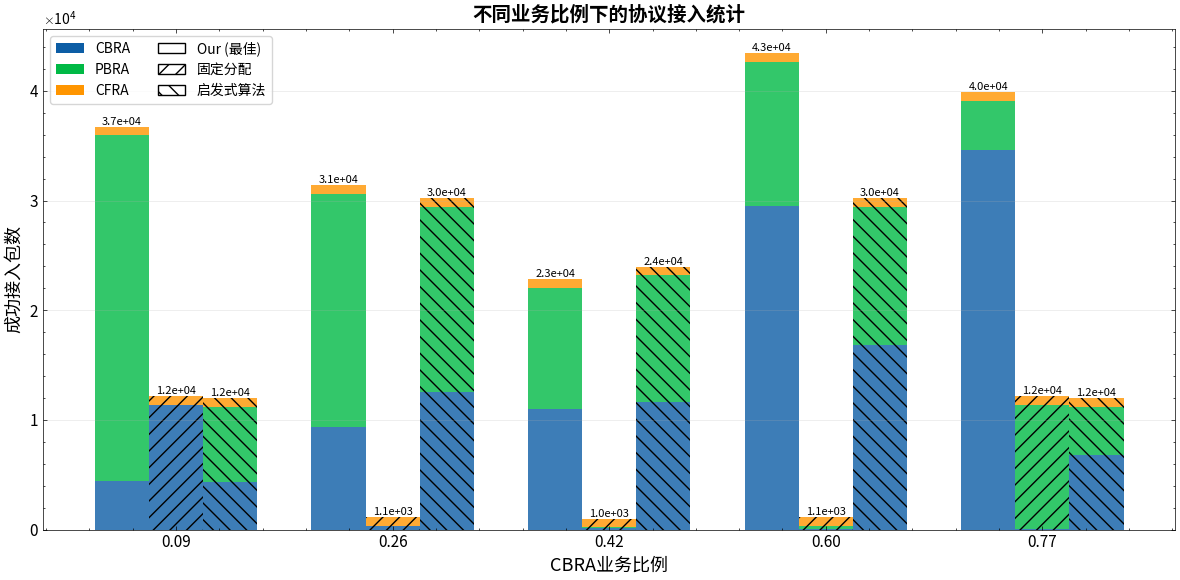

比例扫描对比图已保存到: output/static/ratio_sweep_comparison.svg


In [6]:
def plot_ratio_sweep_results():
    """绘制比例扫描实验结果 - 单图柱状图，X轴为比例，Legend为策略"""
    # 提取数据
    cbra_ratios = []

    # 各策略的各协议成功数
    ppo_cbra = []
    ppo_pbra = []
    ppo_cfra = []
    fixed_cbra = []
    fixed_pbra = []
    fixed_cfra = []
    heuristic_cbra = []
    heuristic_pbra = []
    heuristic_cfra = []

    for scenario_name, result in all_scenarios_results.items():
        if scenario_name.startswith("RatioSweep"):
            parts = scenario_name.split('_')
            cbra_ratio = float(parts[1][1:])

            cbra_ratios.append(cbra_ratio)

            # PPO最佳模型
            ppo_cbra.append(result['eval_results_best']['eval_success_cbra'])
            ppo_pbra.append(result['eval_results_best']['eval_success_pbra'])
            ppo_cfra.append(result['eval_results_best']['eval_success_cfra'])

            # 固定分配
            fixed_cbra.append(result['baseline_results']['固定分配']['success_cbra'])
            fixed_pbra.append(result['baseline_results']['固定分配']['success_pbra'])
            fixed_cfra.append(result['baseline_results']['固定分配']['success_cfra'])

            # 启发式算法
            heuristic_cbra.append(result['baseline_results']['启发式算法']['success_cbra'])
            heuristic_pbra.append(result['baseline_results']['启发式算法']['success_pbra'])
            heuristic_cfra.append(result['baseline_results']['启发式算法']['success_cfra'])

    # 排序
    sorted_indices = np.argsort(cbra_ratios)
    cbra_ratios = np.array(cbra_ratios)[sorted_indices]
    ppo_cbra = np.array(ppo_cbra)[sorted_indices]
    ppo_pbra = np.array(ppo_pbra)[sorted_indices]
    ppo_cfra = np.array(ppo_cfra)[sorted_indices]
    fixed_cbra = np.array(fixed_cbra)[sorted_indices]
    fixed_pbra = np.array(fixed_pbra)[sorted_indices]
    fixed_cfra = np.array(fixed_cfra)[sorted_indices]
    heuristic_cbra = np.array(heuristic_cbra)[sorted_indices]
    heuristic_pbra = np.array(heuristic_pbra)[sorted_indices]
    heuristic_cfra = np.array(heuristic_cfra)[sorted_indices]

    # 计算总数和成功率
    ppo_total = ppo_cbra + ppo_pbra + ppo_cfra
    fixed_total = fixed_cbra + fixed_pbra + fixed_cfra
    heuristic_total = heuristic_cbra + heuristic_pbra + heuristic_cfra

    # 创建单图
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    os.makedirs("output/static", exist_ok=True)

    # 设置柱状图参数
    x = np.arange(len(cbra_ratios))
    width = 0.25

    # 绘制三组堆叠柱状图
    # Our (最佳)
    p1_cbra = ax.bar(x - width, ppo_cbra, width, label='Our-CBRA', alpha=0.8, color='C0')
    p1_pbra = ax.bar(x - width, ppo_pbra, width, bottom=ppo_cbra, label='Our-PBRA', alpha=0.8, color='C1')
    p1_cfra = ax.bar(x - width, ppo_cfra, width, bottom=ppo_cbra+ppo_pbra, label='Our-CFRA', alpha=0.8, color='C2')

    # 固定分配
    p2_cbra = ax.bar(x, fixed_cbra, width, alpha=0.8, color='C0', hatch='//')
    p2_pbra = ax.bar(x, fixed_pbra, width, bottom=fixed_cbra, alpha=0.8, color='C1', hatch='//')
    p2_cfra = ax.bar(x, fixed_cfra, width, bottom=fixed_cbra+fixed_pbra, alpha=0.8, color='C2', hatch='//')

    # 启发式算法
    p3_cbra = ax.bar(x + width, heuristic_cbra, width, alpha=0.8, color='C0', hatch='\\\\')
    p3_pbra = ax.bar(x + width, heuristic_pbra, width, bottom=heuristic_cbra, alpha=0.8, color='C1', hatch='\\\\')
    p3_cfra = ax.bar(x + width, heuristic_cfra, width, bottom=heuristic_cbra+heuristic_pbra, alpha=0.8, color='C2', hatch='\\\\')

    # 在柱子上显示总成功率（基于总到达量）
    for i in range(len(cbra_ratios)):
        # 假设到达量与成功量的比例可以反映成功率
        # 这里简单地在柱子顶部显示总包数的科学计数法
        ax.text(i - width, ppo_total[i], f'{ppo_total[i]:.1e}',
               ha='center', va='bottom', fontsize=8, rotation=0)
        ax.text(i, fixed_total[i], f'{fixed_total[i]:.1e}',
               ha='center', va='bottom', fontsize=8, rotation=0)
        ax.text(i + width, heuristic_total[i], f'{heuristic_total[i]:.1e}',
               ha='center', va='bottom', fontsize=8, rotation=0)

    ax.set_xlabel('CBRA业务比例', fontsize=13)
    ax.set_ylabel('成功接入包数', fontsize=13)
    ax.set_title('不同业务比例下的协议接入统计', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{r:.2f}' for r in cbra_ratios], fontsize=10)

    # 创建自定义图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='C0', label='CBRA'),
        Patch(facecolor='C1', label='PBRA'),
        Patch(facecolor='C2', label='CFRA'),
        Patch(facecolor='white', edgecolor='black', label='Our (最佳)'),
        Patch(facecolor='white', edgecolor='black', hatch='//', label='固定分配'),
        Patch(facecolor='white', edgecolor='black', hatch='\\\\', label='启发式算法'),
    ]
    ax.legend(handles=legend_elements, fontsize=10, frameon=True, loc='upper left', ncol=2)

    ax.tick_params(labelsize=11)
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig("output/static/ratio_sweep_comparison.svg", bbox_inches='tight', dpi=300)
    plt.show()
    print("比例扫描对比图已保存到: output/static/ratio_sweep_comparison.svg")

# 绘制结果
plot_ratio_sweep_results()
